## Find the Number of Cluster 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Elbow method

In [7]:
# Elbow method
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    yy_pred=km.inertia_
    wcss.append(yy_pred)  # inertia_ = WCSS
    print(f"Clusters: {i}, Elbow method: {yy_pred:.3f}")

Clusters: 1, Elbow method: 269981.280
Clusters: 2, Elbow method: 183653.329
Clusters: 3, Elbow method: 106348.373
Clusters: 4, Elbow method: 73880.645
Clusters: 5, Elbow method: 44448.455
Clusters: 6, Elbow method: 40825.169
Clusters: 7, Elbow method: 33642.579
Clusters: 8, Elbow method: 26686.838
Clusters: 9, Elbow method: 24766.472
Clusters: 10, Elbow method: 23103.122


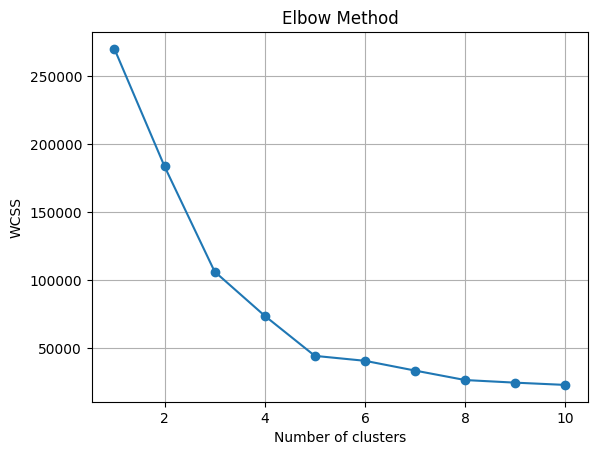

In [8]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

2. ## Silhouette Score

Clusters: 2, Silhouette Score: 0.396
Clusters: 3, Silhouette Score: 0.468
Clusters: 4, Silhouette Score: 0.494
Clusters: 5, Silhouette Score: 0.554
Clusters: 6, Silhouette Score: 0.513
Clusters: 7, Silhouette Score: 0.502
Clusters: 8, Silhouette Score: 0.496
Clusters: 9, Silhouette Score: 0.456
Clusters: 10, Silhouette Score: 0.443


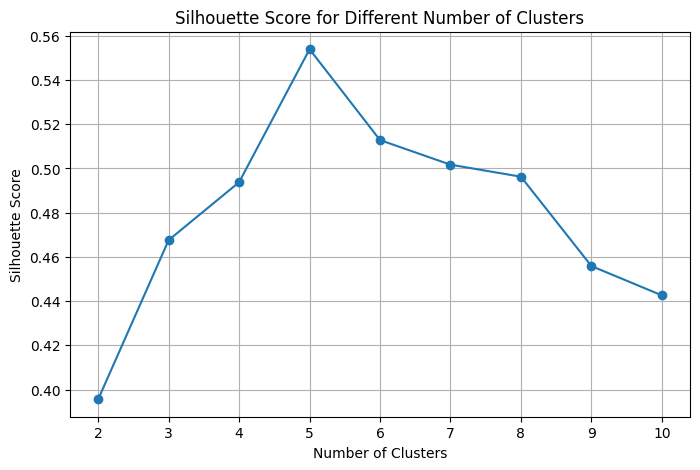

In [6]:
sil_scores = []
cluster_range = range(2, 11)
for i in cluster_range:
    km = KMeans(n_clusters=i, random_state=42)
    y_pred = km.fit_predict(X)
    score = silhouette_score(X, y_pred)
    sil_scores.append(score)
    print(f"Clusters: {i}, Silhouette Score: {score:.3f}")

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(cluster_range, sil_scores, marker='o')
plt.title("Silhouette Score for Different Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

## Using KneeLocator Best Method for all data sets

Optimal number of clusters according to Knee Method: 5


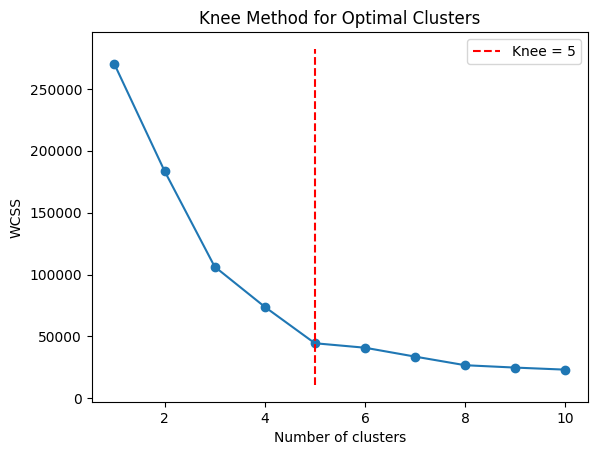

In [9]:
from kneed import KneeLocator
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)
knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
print(f"Optimal number of clusters according to Knee Method: {knee.knee}")
plt.plot(range(1, 11), wcss, marker='o')
plt.vlines(knee.knee, plt.ylim()[0], plt.ylim()[1], linestyles='--', colors='r', label=f'Knee = {knee.knee}')
plt.title("Knee Method for Optimal Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.legend()
plt.show()